# 05 — Market Share Analysis

## How is a fixed market opportunity divided among competing products?

In the previous notebooks, we created a commercial market, explored its products, and queried the generated datasets using SQL.

We will now examine one of the central concepts in pharmaceutical commercial analytics: **market share**.

Market share describes how the total prescribing opportunity is distributed among competing products.

HealthSynth does not generate product prescriptions independently. It first simulates the total market opportunity and then allocates that opportunity according to each product’s adjusted market share.

The overall relationship is:

```text
Monthly Market Demand
        ×
Adjusted Market Share
        =
Product NRx
        ↓
Allocated Across HCPs
```

By the end of this notebook, you will understand:

- the difference between baseline and adjusted market share
- why product shares move over time
- why monthly shares must sum to 100%
- how share determines product-level prescription allocation
- why market share and absolute prescription volume are not the same thing

## Market Share as an Intermediate Commercial Outcome

Market share is often shown as a final dashboard metric.

In HealthSynth, it also has an operational role inside the simulation.

```text
Products and Commercial Activity
        ↓
Competitive Scores
        ↓
Adjusted Market Share
        ↓
Product Demand
        ↓
Prescription Allocation
```

This means market share is both:

- an analytical output that can be studied
- an upstream input into prescription generation

A change in market share therefore affects downstream NRx without changing the total size of the market.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

## Generate the Oncology Market

We will use the oncology training profile.

This profile contains several products competing within the same therapeutic area.

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    output_dir="../output/notebook_05_market_share",
)

In [4]:
products = datasets["product"].copy()
market_share = datasets["market_share"].copy()
market_demand = datasets["market_demand"].copy()
prescriptions = datasets["prescriptions"].copy()

## Prepare the Data

The market-share table identifies products by `product_id`.

We will join descriptive product information from the product master and convert the monthly period to a datetime value.

In [5]:
market_share["month"] = pd.to_datetime(
    market_share["month"]
)

market_demand["month"] = pd.to_datetime(
    market_demand["month"]
)

prescriptions["rx_date"] = pd.to_datetime(
    prescriptions["rx_date"]
)

market_share_named = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
            "manufacturer",
            "brand_type",
        ]
    ],
    on="product_id",
    how="left",
)

## Meet the Competing Products

Before analysing market movement, let us review the configured product portfolio.

In [6]:
product_columns = [
    column
    for column in [
        "product_id",
        "product_name",
        "manufacturer",
        "brand_type",
        "therapeutic_area",
        "launch_date",
        "baseline_market_share",
    ]
    if column in products.columns
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,therapeutic_area,launch_date,baseline_market_share
0,P001,OncoNova,NVA Pharma,Innovator,Oncology,2023-01-01,0.45
1,P002,Tumora,Competitor A,Competitor,Oncology,2022-07-01,0.35
2,P003,Immunex,Competitor B,Competitor,Oncology,2021-01-01,0.20


## Baseline Market Share

`baseline_market_share` represents the configured competitive starting point or mature potential of a product.

For example, a baseline share of `0.50` means the product begins with a nominal competitive weight of 50%.

It does **not** guarantee that the product will hold exactly 50% share every month.

Observed share can also be influenced by:

- promotional activity
- product availability
- launch adoption
- loss of exclusivity
- market access
- competitive redistribution
- controlled random variation

In [7]:
baseline_share = (
    products[
        [
            "product_name",
            "baseline_market_share",
        ]
    ]
    .sort_values(
        "baseline_market_share",
        ascending=False,
    )
)

baseline_share

,product_name,baseline_market_share
0,OncoNova,0.45
1,Tumora,0.35
2,Immunex,0.20


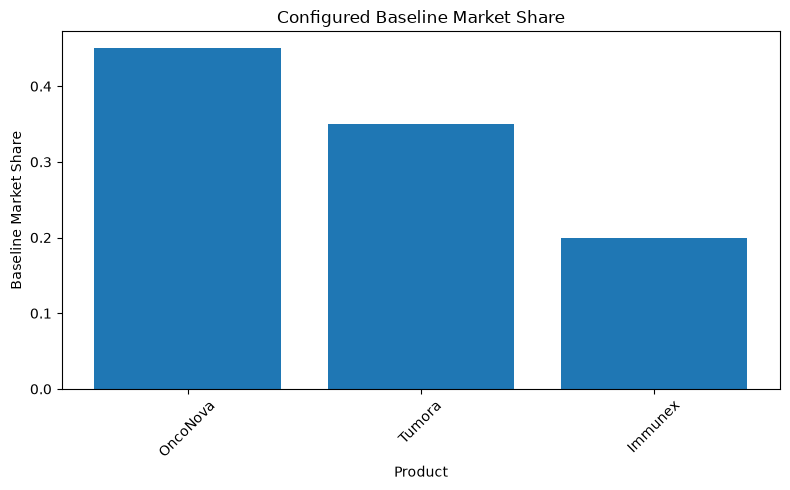

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_share["product_name"],
    baseline_share["baseline_market_share"],
)

plt.title("Configured Baseline Market Share")
plt.xlabel("Product")
plt.ylabel("Baseline Market Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The baseline values describe the competitive assumptions encoded in the profile.

They provide a reference point, but the simulation calculates a new adjusted share for each product and month.

A useful distinction is:

```text
Baseline Share
    = configured assumption

Adjusted Market Share
    = simulated monthly outcome
```

## Inspect the Monthly Market-Share Dataset

The market-share table contains one row for each product and month.

In [9]:
market_share_columns = [
    column
    for column in [
        "month",
        "product_id",
        "product_name",
        "baseline_market_share",
        "base_adoption_factor",
        "promotion_acceleration",
        "effective_adoption_factor",
        "loe_factor",
        "market_access_factor",
        "adjusted_market_share",
    ]
    if column in market_share_named.columns
]

market_share_named[
    market_share_columns
].head(10)

,month,product_id,product_name,baseline_market_share,base_adoption_factor,promotion_acceleration,effective_adoption_factor,loe_factor,market_access_factor,adjusted_market_share
0,2023-01-01,P001,OncoNova,0.45,1.0,0.0,1.0,1.0,1.0,0.419635
1,2023-01-01,P002,Tumora,0.35,1.0,0.0,1.0,1.0,1.0,0.358438
2,2023-01-01,P003,Immunex,0.20,1.0,0.0,1.0,1.0,1.0,0.221927
3,2023-02-01,P001,OncoNova,0.45,1.0,0.0,1.0,1.0,1.0,0.436143
4,2023-02-01,P002,Tumora,0.35,1.0,0.0,1.0,1.0,1.0,0.338724
5,2023-02-01,P003,Immunex,0.20,1.0,0.0,1.0,1.0,1.0,0.225133
6,2023-03-01,P001,OncoNova,0.45,1.0,0.0,1.0,1.0,1.0,0.415505
7,2023-03-01,P002,Tumora,0.35,1.0,0.0,1.0,1.0,1.0,0.360392
8,2023-03-01,P003,Immunex,0.20,1.0,0.0,1.0,1.0,1.0,0.224102
9,2023-04-01,P001,OncoNova,0.45,1.0,0.0,1.0,1.0,1.0,0.426871


Some columns may remain neutral in this profile:

- adoption factors are normally `1.0` for mature products
- the LOE factor is `1.0` when no loss-of-exclusivity event is configured
- the market-access factor is `1.0` when no access event is configured

Later scenario notebooks deliberately change these values.

For now, our goal is to understand the core market-share output.

## Market Share Over Time

We will pivot the data so that each product becomes a separate series.

In [10]:
share_pivot = market_share_named.pivot(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

share_pivot.head()

product_name,Immunex,OncoNova,Tumora
month,,,
2023-01-01,0.221927,0.419635,0.358438
2023-02-01,0.225133,0.436143,0.338724
2023-03-01,0.224102,0.415505,0.360392
2023-04-01,0.228313,0.426871,0.344816
2023-05-01,0.230566,0.423808,0.345626


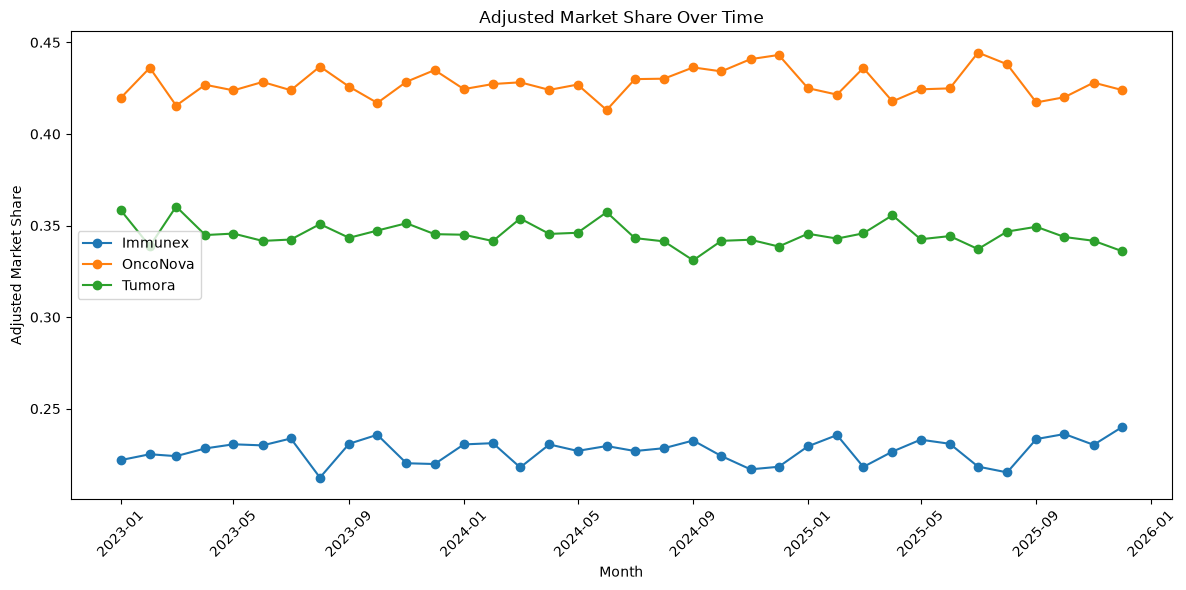

In [11]:
plt.figure(figsize=(12, 6))

for product_name in share_pivot.columns:
    plt.plot(
        share_pivot.index,
        share_pivot[product_name],
        marker="o",
        label=product_name,
    )

plt.title("Adjusted Market Share Over Time")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What Should We Notice?

Market share may move slightly from month to month even when no major commercial event occurs.

That movement can reflect:

- changing promotional effects
- variation in product competitive scores
- controlled simulation noise
- normalization across all competing products

Because the products compete within the same market, one product’s gain must be balanced by losses elsewhere.

Market share is therefore a **relative measure**.

## The Conservation Rule

Within a therapeutic area and month, all adjusted product shares must sum to `1.0`.

```text
Product A Share
    +
Product B Share
    +
Product C Share
    =
100% of the Market
```

This is one of the most important business rules in the simulation.

In [12]:
monthly_share_totals = (
    market_share_named.groupby(
        [
            "therapeutic_area",
            "month",
        ]
    )["adjusted_market_share"]
    .sum()
    .reset_index(name="total_market_share")
)

monthly_share_totals.head()

,therapeutic_area,month,total_market_share
0,Oncology,2023-01-01,1.0
1,Oncology,2023-02-01,1.0
2,Oncology,2023-03-01,1.0
3,Oncology,2023-04-01,1.0
4,Oncology,2023-05-01,1.0


In [13]:
monthly_share_totals["difference_from_one"] = (
    monthly_share_totals["total_market_share"] - 1.0
)

monthly_share_totals[
    [
        "month",
        "therapeutic_area",
        "total_market_share",
        "difference_from_one",
    ]
].head()

,month,therapeutic_area,total_market_share,difference_from_one
0,2023-01-01,Oncology,1.0,-1.110223e-16
1,2023-02-01,Oncology,1.0,0.000000e+00
2,2023-03-01,Oncology,1.0,-1.110223e-16
3,2023-04-01,Oncology,1.0,2.220446e-16
4,2023-05-01,Oncology,1.0,-1.110223e-16


In [14]:
assert (
    monthly_share_totals[
        "total_market_share"
    ].sub(1.0).abs() < 1e-9
).all()

print("Every monthly market-share total equals 1.0.")

Every monthly market-share total equals 1.0.


## From Market Share to Product Demand

Market share becomes commercially meaningful when it is combined with total market demand.

For each product and month:

```text
Product NRx Opportunity
        =
Monthly Market NRx
        ×
Adjusted Market Share
```

Suppose the market contains 1,000 NRx in a month:

```text
Product A share = 50% → approximately 500 NRx
Product B share = 30% → approximately 300 NRx
Product C share = 20% → approximately 200 NRx
```

HealthSynth uses this relationship before allocating product NRx across individual HCPs.

In [15]:
monthly_product_demand = market_share_named.merge(
    market_demand[
        [
            "market_id",
            "month",
            "therapeutic_area",
            "market_nrx",
        ]
    ],
    on=[
        "market_id",
        "month",
        "therapeutic_area",
    ],
    how="left",
)

monthly_product_demand["unrounded_expected_nrx"] = (
    monthly_product_demand["adjusted_market_share"]
    * monthly_product_demand["market_nrx"]
)

monthly_product_demand[
    [
        "month",
        "product_name",
        "market_nrx",
        "adjusted_market_share",
        "unrounded_expected_nrx",
    ]
].head(10)

,month,product_name,market_nrx,adjusted_market_share,unrounded_expected_nrx
0,2023-01-01,OncoNova,663,0.419635,278.217932
1,2023-01-01,Tumora,663,0.358438,237.644440
2,2023-01-01,Immunex,663,0.221927,147.137628
3,2023-02-01,OncoNova,684,0.436143,298.321479
4,2023-02-01,Tumora,684,0.338724,231.687409
5,2023-02-01,Immunex,684,0.225133,153.991112
6,2023-03-01,OncoNova,739,0.415505,307.058441
7,2023-03-01,Tumora,739,0.360392,266.329981
8,2023-03-01,Immunex,739,0.224102,165.611578
9,2023-04-01,OncoNova,741,0.426871,316.311286


The expected value may contain decimals.

Prescription counts must be whole numbers, so HealthSynth uses an allocation method that:

- converts product demand into integer counts
- preserves the total monthly market NRx
- keeps the allocation as close as possible to the calculated shares

This may create small rounding differences at the product level, while the monthly market total remains exact.

## Compare Expected and Generated Product NRx

We will aggregate the generated prescription records by product and month.

In [16]:
generated_product_nrx = (
    prescriptions.groupby(
        [
            "rx_date",
            "product_id",
        ]
    )["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

generated_product_nrx = generated_product_nrx.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

generated_product_nrx.head()

,month,product_id,generated_nrx,product_name
0,2023-01-01,P001,282,OncoNova
1,2023-01-01,P002,231,Tumora
2,2023-01-01,P003,150,Immunex
3,2023-02-01,P001,311,OncoNova
4,2023-02-01,P002,220,Tumora


In [17]:
allocation_comparison = (
    monthly_product_demand[
        [
            "month",
            "product_id",
            "product_name",
            "market_nrx",
            "adjusted_market_share",
            "unrounded_expected_nrx",
        ]
    ]
    .merge(
        generated_product_nrx[
            [
                "month",
                "product_id",
                "generated_nrx",
            ]
        ],
        on=[
            "month",
            "product_id",
        ],
        how="left",
    )
)

allocation_comparison["allocation_difference"] = (
    allocation_comparison["generated_nrx"]
    - allocation_comparison["unrounded_expected_nrx"]
)

allocation_comparison.head(10)

,month,product_id,product_name,market_nrx,adjusted_market_share,unrounded_expected_nrx,generated_nrx,allocation_difference
0,2023-01-01,P001,OncoNova,663,0.419635,278.217932,282,3.782068
1,2023-01-01,P002,Tumora,663,0.358438,237.644440,231,-6.644440
2,2023-01-01,P003,Immunex,663,0.221927,147.137628,150,2.862372
3,2023-02-01,P001,OncoNova,684,0.436143,298.321479,311,12.678521
4,2023-02-01,P002,Tumora,684,0.338724,231.687409,220,-11.687409
5,2023-02-01,P003,Immunex,684,0.225133,153.991112,153,-0.991112
6,2023-03-01,P001,OncoNova,739,0.415505,307.058441,310,2.941559
7,2023-03-01,P002,Tumora,739,0.360392,266.329981,257,-9.329981
8,2023-03-01,P003,Immunex,739,0.224102,165.611578,172,6.388422
9,2023-04-01,P001,OncoNova,741,0.426871,316.311286,280,-36.311286


### Interpretation

Generated product NRx should remain close to:

```text
market_nrx × adjusted_market_share
```

Small differences are expected because prescriptions are integer counts.

The more important reconciliation occurs at the total market level.

## Reconcile Total Prescriptions to Market Demand

When product allocations are added together, total generated NRx should exactly match monthly market demand.

In [18]:
monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

market_reconciliation = market_demand[
    [
        "month",
        "market_nrx",
    ]
].merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

market_reconciliation["difference"] = (
    market_reconciliation["generated_nrx"]
    - market_reconciliation["market_nrx"]
)

market_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-01-01,663,663,0
1,2023-02-01,684,684,0
2,2023-03-01,739,739,0
3,2023-04-01,741,741,0
4,2023-05-01,766,766,0


In [19]:
assert (
    market_reconciliation["difference"] == 0
).all()

print(
    "Monthly generated NRx reconciles exactly "
    "with simulated market demand."
)

Monthly generated NRx reconciles exactly with simulated market demand.


## Total NRx by Product

We can now look at the total prescription volume allocated to each product across the full simulation.

In [20]:
total_nrx_by_product = (
    generated_product_nrx.groupby(
        "product_name"
    )["generated_nrx"]
    .sum()
    .reset_index()
    .sort_values(
        "generated_nrx",
        ascending=False,
    )
)

total_nrx_by_product

,product_name,generated_nrx
1,OncoNova,12788
2,Tumora,10290
0,Immunex,6916


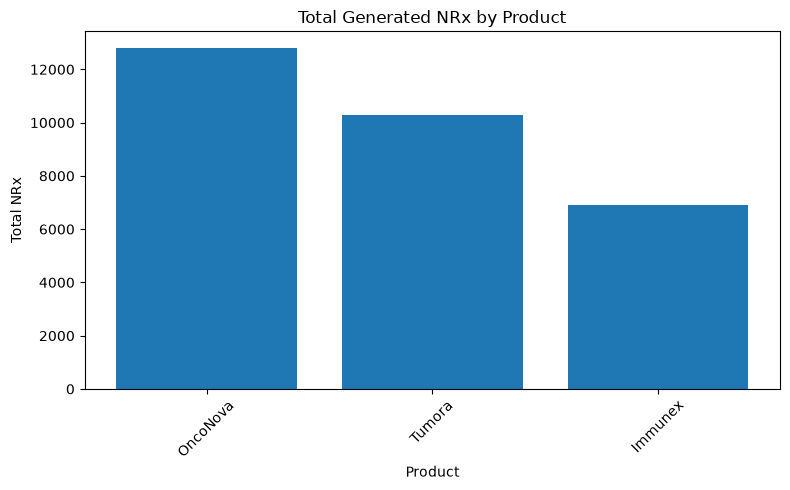

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    total_nrx_by_product["product_name"],
    total_nrx_by_product["generated_nrx"],
)

plt.title("Total Generated NRx by Product")
plt.xlabel("Product")
plt.ylabel("Total NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Market Share and Prescription Volume Are Different Measures

A product’s market share is relative to its competitors.

Its prescription volume is also affected by the size of the total market.

This creates an important commercial possibility:

> A product can lose market share while still gaining prescriptions.

For example:

```text
Year 1:
Market demand = 1,000
Product share = 40%
Product NRx = 400

Year 2:
Market demand = 1,500
Product share = 35%
Product NRx = 525
```

The product lost five percentage points of share but gained 125 prescriptions because the overall market grew.

Notebook 06 explores this relationship in greater detail.

## Why Analysts Examine Both Measures

Market share answers:

> How are we performing relative to competitors?

Prescription volume answers:

> How much business are we generating?

The two measures should be interpreted together.

A product may:

- gain both share and prescriptions
- lose both share and prescriptions
- lose share but gain prescriptions
- gain share in a shrinking market and still lose prescriptions

Commercial performance cannot always be understood from a single metric.

## Key Takeaways

In this notebook, we learned that:

- baseline share is a configured competitive assumption
- adjusted market share is a simulated monthly outcome
- market share is relative and must sum to 100% each month
- market demand determines the total prescription opportunity
- adjusted share determines each product’s portion of that opportunity
- generated prescriptions are allocated from upstream market dynamics
- integer allocation may create small product-level rounding differences
- total monthly generated NRx reconciles exactly with market demand
- market share and absolute NRx answer different commercial questions

HealthSynth therefore uses the following connected model:

```text
Market Demand
        ×
Adjusted Market Share
        =
Product Demand
        ↓
HCP Prescription Allocation
```

## Try It Yourself

### Experiment 1 — Change Baseline Share

Create a copy of the oncology profile and adjust the baseline market shares.

Make sure the values still sum to `1.0`.

Before rerunning, predict:

- Which product will gain share?
- Which products will lose share?
- How will total market NRx change?

---

### Experiment 2 — Change Promotion

Change the promotional channel assumptions or activity level.

Observe whether adjusted market share changes while baseline share remains fixed.

---

### Experiment 3 — Compare One Month

Choose a single month and calculate manually:

```python
market_nrx * adjusted_market_share
```

Compare the result with generated product NRx.

How large is the rounding difference?

---

### Experiment 4 — Compare Relative and Absolute Performance

Identify two months where a product’s market share declined.

Did its NRx also decline?

What happened to total market demand?

## What's Next?

Market share tells us how a market is divided.

But it does not tell us how large the market is or why total prescribing volume changes.

In Notebook 06, we will examine **Market Demand and Growth**.

We will explore:

- total market volume
- growth
- seasonality
- the difference between share and demand
- how a product can lose share while still gaining prescriptions

Notebook 05 explained how the opportunity is divided.

Notebook 06 explains how the opportunity itself changes.